# Group Report 1

## Part One: GETTING TO KNOW GRAPHS
### 1: Defining a Graph

A graph is a mathematical structure G=(V,E) where V is the set of vertices or nodes, and E is the set of edges or links connecting pairs of vertices (Ajorlou, 2018). Graphs represent objects and the relationships between them. An example of this is in a student collaboration network, each vertex represents a student, and an edge connects two students who have worked on a project together.

A graph is usually drawn using points for vertices and lines for edges. However, the connections matter more than the positions of the points. Moving the points without changing their connections still represents the same graph. In graph theory, a graph descibes a network of relationships. This is different than a graph of a function which shows how one numerial variable changes with another. 

When describing a network, we also need to specify which kinds of connections are allowed. A simple graph has no self-loops, which are edges connecting a vertex to itself, and no multiple edges between the same pair of vertices. More general graphs can allow these features, depending on the relationships being modeled (Ajorlou, 2018).

### 2: Vertices and Edges

To describe the connections precisely, graph theory uses the terms adjacency and incidence. Two vertices are adjacent(or neighbors) when an edge joins them. An edge is incident to each vertex it connects, and these vertices are called its endpoints. Adjacency describes a relationship between two vertices, while incidence describes a relationship between an edge and vertex (Ajorlou, 2018).

The neighborhood of a vertex contains all the vertices directly connected to it by an edge. For examnple, if B is connected to A and C, its neighborhood is {A,C}. Two edges can also share an endpoint. The edges {A,B} and {B,C} both connect to B, so B is their shared endpoint (Ajorlou, 2018).

In the vertex set V = {A,B,C,D} and the edge set E = {{A,B},{B,C}}. This graph has four vertices and two edges. The edge {A,B} has endpoints A and B, while the {B,C} has endpoints B and C. Also, Vertex D belongs to the graph even though no edge connects it to another vertex, so it is a isolated vertex.

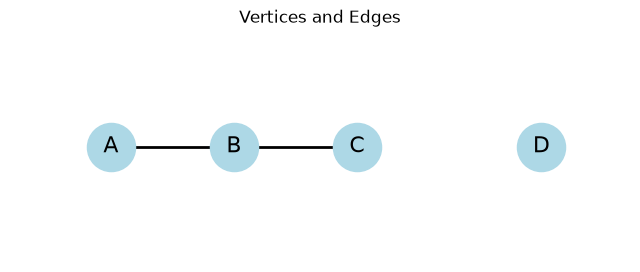

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(["A", "B", "C", "D"])
G.add_edges_from([("A", "B"), ("B", "C")])

positions = {"A": (0,0), "B": (1,0), "C":(2,0), "D": (3.5,0)}
plt.figure(figsize = (8,3))
nx.draw_networkx(G, pos = positions, node_color = "lightblue", node_size = 1200, font_size= 16, width = 2)
plt.title("Vertices and Edges")
plt.margins(0.2)
plt.axis("off")
plt.show()

Figure 1: A graph with four vertices and two edges. The two edges share endpoint B, while D is isolated. 

From the figure, the neighborhood of B is {A,C}, while the neighborhood of A is {B}. Vertex D has an empty neighborhood since it has no incident edges. D still belongs to the vertex set, showing that a vertex can exist in a graph without having any connections. 

### 3: Directed and Undirected graphs

An undirected graph has edges without direction. An edge connecting A and B represents the same connections from either endpoint is drawn as a line without an error (Sedgewick & Wayne, n.d.). An example of this is a collaboration between two students that can be modeled as an undirected relationship because both students participate in the same connection.

A directed graph which is also called a digraph, has edges with a specific direction. These edges are drawn as arrows. An arrow from A to B represents a connection from A to B, but it doesn't automatically mean that there is a connection from B to A. Also, A can point to B, and B can point to A, but they are two separate directed edges (Nykamp, n.d.). Links between web pages can illustrate why direction matters. One page can link to another without receiving a link back. A directed graph shows which page the link comes from and which page it points to (Nykamp, n.d.). 

To compare the two types, consider the vertices A, B, and C arranged in a triangle. In the undirected example, edges connect A to B, B to C, and C to A without arrows. While in the directed example, arrows point from A to B, B to C, and C to A. 

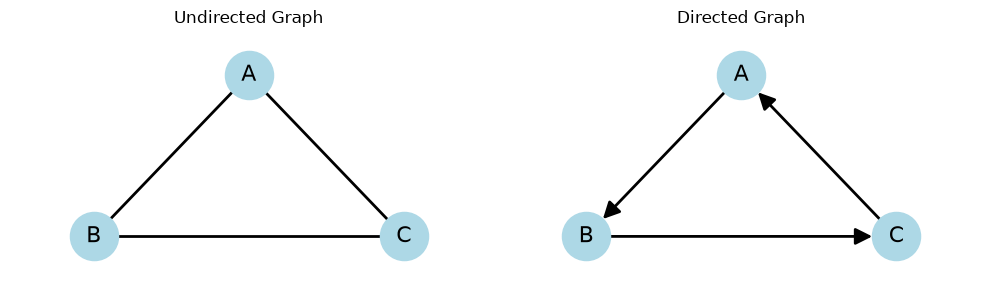

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

undirected = nx.Graph()
undirected.add_edges_from([("A", "B"), ("B", "C"), ("C", "A")])

directed = nx.DiGraph()
directed.add_edges_from([("A", "B"), ("B", "C"), ("C","A")])

positions = {"A": (0,1), "B": (-1,-0.5), "C": (1,-0.5)}
fig, axes = plt.subplots(1, 2,figsize = (10, 3)) 

nx.draw_networkx( undirected, pos = positions, ax = axes[0], node_color = "lightblue", node_size = 1200, font_size = 16, width = 2)
axes[0].set_title("Undirected Graph")

nx.draw_networkx(directed, pos = positions, ax = axes[1], node_color = "lightblue",node_size = 1200, font_size = 16, width = 2, arrows = True, arrowsize = 25)

axes[1].set_title("Directed Graph")

for ax in axes:
    ax.margins(0.2)
    ax.axis("off")

plt.tight_layout()
plt.show()


Figure 2: Undirected and directed graphs with three vertices and three edges each. The undirected graph has no arrows, while the directed graph has arrows from A to B, B to C, and C to A.

Both graphs connect the same pairs of vertices, but direction changes how the connections can be followed. In the undirected graph, the edge between A and C can be followed either way. However in the directed graph, the edge points only from C to A. To reach C from A while following the arrows, we must go through B. 

### 4: Weighted and Unweighted graphs

An unweighted graph records whether a connection exists without assigning a numerical weight to each edge. A weighted graph adds a number to each edge to describe something about that connection. Depending on the model, weights might represent distance, travel time, cost, or the strength of an interaction (Ajorlou, 2018; Nykamp, n.d.).

Each weight needs a clear meaning. A larger number could indicate a longer journey in a transportation network or a stronger interaction in a social network. Therefore, larger weights do not always mean better connections.

For an example, consider three locations labeled A, B, and C. All three pairs have a direct route. In the unweighted graph, the edges show only the routes. In the weighted graph, suppose the travel times are 4 minutes between A and B, 3 minutes between B and C, and 10 minutes between A and C.

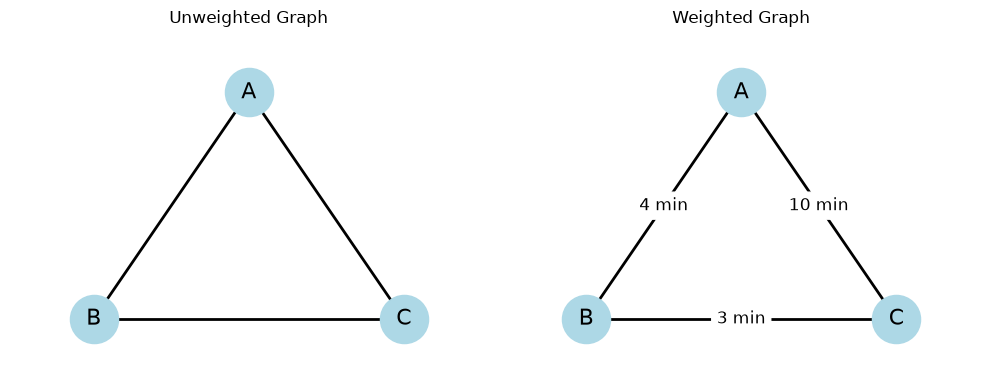

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

unweighted = nx.Graph()
unweighted.add_edges_from([("A", "B"), ("B", "C"), ("C", "A")])

weighted = nx.Graph()
weighted.add_weighted_edges_from([("A", "B", 4), ("B", "C", 3), ("A", "C", 10)])

positions = {"A": (0,1), "B": (-1,-0.5), "C": (1,-0.5)}
fig, axes = plt.subplots(1, 2,figsize = (10, 4)) 

for graph, ax in zip([unweighted, weighted], axes):
    nx.draw_networkx(graph, pos = positions, ax = ax, node_color = "lightblue", node_size = 1200, font_size = 16, width = 2)
    ax.margins(0.2)
    ax.axis("off")
axes[0].set_title("Unweighted Graph")
axes[1].set_title("Weighted Graph")

edge_labels = {(u,v) : f"{data['weight']} min"
               for u, v, data in weighted.edges(data = True)}

nx.draw_networkx_edge_labels(weighted, pos= positions, edge_labels = edge_labels, ax = axes[1], font_size = 12, rotate = False)

plt.tight_layout()
plt.show()

    

                                  

Figure 3: Unweighted and weighted graphs with the same three vertices and edges. In the weighted graph, the edge labels represent travel times of 4, 3, 10 minutes.

In the weighted example, traveling directly from A to C takes 10 minutes, while traveling through B takes 7 minutes( 4+ 3). Although the route through B uses more edges, it takes less time. This shows how weights provide information that the unweighted graph does not record. 

Direction and weight are separate features. Both graphs in Figure 3 are undirected, but directed graphs can also have weights, such as one-way roads labeled with travel times.

## Part Two: STRONGLY REGULAR GRAPHS

### 1: Defining a Strongly Regular Graph
- **Combinatorial Definition:**
    1. for integer $k$, has $k$ number of neighbors
    2. for integer $λ$ as common neighbors, if vertices $x$ & $y$ share an edge, they also share the same number of mutual neighbors, vertices $z$
    3. for vertices $x$ & $y$ which are not neighbors (that don't share an edge) have the same number $μ$ of vertices $z$ as neighbors
- **Spectral Definition:**
    - A strongly regular graph is a finite regular graph with exactly 2 restricted eigenvalues
- These two definitions are proven to be equal by the $A^2$ identity, which uses the parameters $k, λ, µ,$ where $A$ is the Adjacency matrix of a Strongly Regular Graph with the eigenvalue $k$
- The $A^2$ identity is therefore able to prove that A has 2 eigenvalues using the parameter $k, λ, µ$
    - $A^2 = λA + µ(J − I − A) + kI = (λ − µ)A + µJ + (k − µ)I$

Strongly regular graphs are defined by Brouwer and Van Maldeghem as a "finite regular graph with precisely two restricted eigenvalues." (Brouwer & Van Maldeghem, 2022) The *graph* $X$ is a set of elements called vertices, where each pair of vertices may share a two-way, symmetric relationship called *adjacency*, such that no vertex is adjacent to itself. The pair of vertices $xy$ is an *edge* where y is the *neighbor* of x.

The adjacency matrix $A$ represents the connections of graph $X$. The table representation of this matrix has one row and one column for each vertex, with each cell comparing a pair of vertices. If $x$ and $y$ are vertices and $xy$ is an edge, then $A_{xy}=1$. If $x$ and $y$ are vertices and $xy$ is not an edge, then $A_{xy}=0$.

Consider the adjacency matrix $A$ acting as a transformation. Inputting a vector into this matrix may output a new vector pointing in a different direction. For special vectors $v$, multiplying by $A$ does not change the direction of $v$, instead it only stretches or shrinks this vector by some factor. $v$ is an eigenvector, and the stretching factor is its eigenvalue, often represented by $\theta$.

The number of specific eigenvectors which share the same eigenvalue is the eigenvalue's *multiplicity* and the complete list of a matrix's eigenvalues with their multiplicities is called the *spectrum*. The graph $X$ is of *regular* *degree* (also known as *valency*) for some integer $k$, when every vertex has precisely $k$ neighbors.

If every vertex has the same degree $k$, then the all-1s vector (a vector with each component equal to 1) will always be scaled exactly by $k$. This vector will be an eigenvector with eigenvalue $k$ if and only if $X$ is regular and of degree $k$ (Brouwer & Van Maldeghem, 2022). With this in mind, the multiplicity of the eigenvalue $k$ will be the number of connected components of $X$ (Brouwer & Van Maldeghem, 2022). Importantly, for the definition of a strongly regular graph, an eigenvalue $\theta$ of this regular graph is referred to as *restricted* if it produces an eigenvector orthogonal to the all-1 vector (Brouwer & Van Maldeghem, 2022). Two vectors $u = [u1, u2, u3, u4]$ and $w = [w1, w2, w3, w4]$ are orthogonal exactly when their dot product is 0.\\
$u \cdot w = (u_1 \times w_1) + (u_2 \times w_2) + (u_3 \times w_3) + (u_4 \times w_4) = 0$

With all of this in mind, a finite regular graph without restricted eigenvalues has at most one vertex, while a finite regular graph with only one restricted eigenvalue is *complete* or *edgeless* (Brouwer & Van Maldeghem, 2022). Circling back to Brouwer and Van Maldeghem's definition, "A *strongly regular graph* is a finite regular graph with precisely two restricted eigenvalues" (Brouwer & Van Maldeghem, 2022). This means that the graph not only has a fixed degree, but also reflects the fact that every pair of adjacent vertices shares another fixed number of common neighbors everywhere in the graph - regardless of its size.

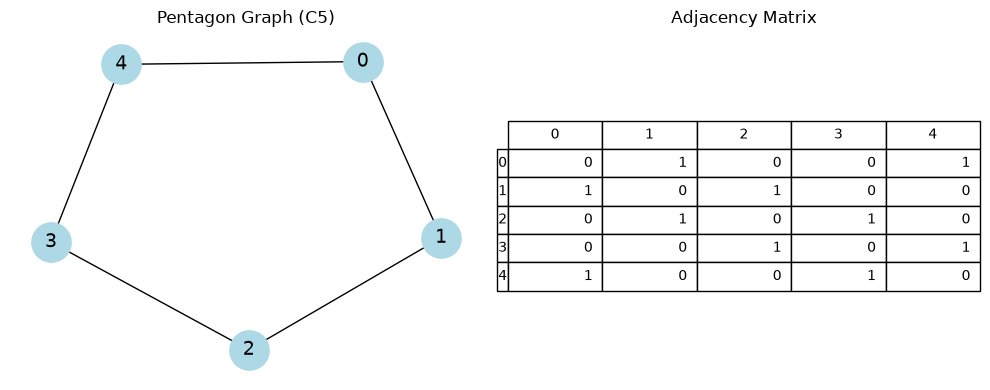

Step 1: Degree of each vertex: [2, 2, 2, 2, 2]
Is every vertex the same degree (regular)? True
Degree k = 2

Step 2: Common neighbors for each adjacent pair:
 Vertices 0 and 1 (adjacent): 0 common neighbors
 Vertices 0 and 4 (adjacent): 0 common neighbors
 Vertices 1 and 2 (adjacent): 0 common neighbors
 Vertices 2 and 3 (adjacent): 0 common neighbors
 Vertices 3 and 4 (adjacent): 0 common neighbors

Step 2: Common neighbors for each non-adjacent pair:
 Vertices 0 and 2 (non-adjacent): 1 common neighbors
 Vertices 0 and 3 (non-adjacent): 1 common neighbors
 Vertices 1 and 3 (non-adjacent): 1 common neighbors
 Vertices 1 and 4 (non-adjacent): 1 common neighbors
 Vertices 2 and 4 (non-adjacent): 1 common neighbors

Step 4: Since every adjacent pair shares the same number of common neighbors (lambda),
and every non-adjacent pair shares the same number of common neighbors (mu),
this graph satisfies the strongly regular graph condition: SRG(v, k, lambda, mu).
Step 5: Eigenvalues of adjacenc

In [4]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# "Pentagon Graph" (C_5) -> smallest strongly regular graph SRG(5,2,0,1)
# v = 5 (vertices), k = 2 (degree), lambda = 0 (adjacent vertices with common neighbors), mu = 1 (non-adjacent vertices sharing 1 common neighbor)
G = nx.cycle_graph(5)
A = nx.to_numpy_array(G, dtype=int)
df = pd.DataFrame(A, index=G.nodes(), columns=G.nodes())

# create a figure with 1 row and 2 columns of plots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# draw the graph G into the LEFT plot (axes[0])
# with_labels=True shows vertex numbers, node_color/node_size control appearance
nx.draw(G, with_labels=True, node_color='lightblue', node_size=800, font_size=14, ax=axes[0])
axes[0].set_title("Pentagon Graph (C5)")  # add a title above the left plot

# turn off the x/y axis lines and numbers for the RIGHT plot
axes[1].axis('off')

# build a table inside the right plot using our adjacency matrix DataFrame (df)
# cellText = the actual 0/1 values, rowLabels/colLabels = the vertex numbers along the edges
table = axes[1].table(cellText=df.values, rowLabels=df.index, colLabels=df.columns, loc='center')
table.scale(1, 1.5)  # stretch the table slightly taller so it's easier to read
axes[1].set_title("Adjacency Matrix")  # add a title above the right plot

# arrange everything neatly so titles/labels don't overlap
plt.tight_layout()

# actually display the finished figure
plt.show()

# --STEP 1: Check if regular--
# determining if graph is strongly regular
degrees = [deg for node, deg in G.degree()] # G.degree() -> (vertex, degree) *pulling out degree numbers into list
print("Step 1: Degree of each vertex:", degrees) # print degree of every vertex
# set(degrees) removes duplicates from list of degrees -> if one unique value every vertex has the same degree
print("Is every vertex the same degree (regular)?", len(set(degrees)) == 1) # len is number of vals in set -> if one unique value then ouptut will be TRUE
k = degrees[0] # all degrees are equal, so first one can be k
print(f"Degree k = {k}") # print k

#--STEP 2: Check common neighbors for each adjacent pair (all should equal lambda)--
print("\nStep 2: Common neighbors for each adjacent pair:")
# G.edges() returns every edge as pair of vertices (x,y)
for x, y in G.edges():
    common = len(list(nx.common_neighbors(G, x, y)))
    print(f" Vertices {x} and {y} (adjacent): {common} common neighbors")

#--STEP 3: Check common neighbors for every non-adjacent pair (all should equal mu)--
print("\nStep 2: Common neighbors for each non-adjacent pair:")
nodes = list(G.nodes()) # get plain list of all vertex labels
# loop through every unique vertice pair (i,j) without repeating pairs or comparing vertex to itself
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        x, y = nodes[i], nodes[j]
        if not G.has_edge(x, y): # only check pairs not connected by an edge
            common = len(list(nx.common_neighbors(G, x, y)))
            print(f" Vertices {x} and {y} (non-adjacent): {common} common neighbors")

#--STEP 4: Conclusion based on combinatorial process--
print("\nStep 4: Since every adjacent pair shares the same number of common neighbors (lambda),")
print("and every non-adjacent pair shares the same number of common neighbors (mu),")
print("this graph satisfies the strongly regular graph condition: SRG(v, k, lambda, mu).")

#--STEP 5: Verify using eigenvalue process--
# compute eigenvalues of adjacency matrix A
eigenvalues, eigenvectors = np.linalg.eig(A)
eigenvalues_rounded = np.round(eigenvalues, 2) # round eigenvalues

print("Step 5: Eigenvalues of adjacency matrix:")
print(eigenvalues_rounded)

# count how many distinct eigenvalues there are
distinct_eigenvalues = set(eigenvalues_rounded)
print(f"\nNumber of distinct eigenvalues: {len(distinct_eigenvalues)}")
print("One of these is k (the degree). The remaining distinct values are the 'restricted' eigenvalues.")
print("A strongly regular graph should have exactly 2 restricted eigenvalues (3 distinct total, including k).")

### 2: Importance of Strongly Regular Graphs in Combinatorics, Abstract Algebra, and Coding Theory

#### 2.1: SRG in Combinatorics

Strongly Regular Graphs are a fundamental aspect of study within combinatorics, a type of mathematics which deals with counting, arranging, and organizing objects, without the use of calculus or continuous math. Many well known strongly regular graphs are derived from combinatorial constructions like Latin Square Graphs.  

- Latin Squares are an $n$ $\times$ $n$ grid where each number spans between 1 and $n$, with absolutely no repeating numbers in a row or column. Latin Square Graphs are then constructed from Latin Squares, where each cell in the grid becomes a vertex (also known as nodes) and the number of nodes an LSG has is found using $n^2$. Two nodes share an edge if they are in the same column, row, or if they are simply the same number regardless of which row or column.
  
- To find $k$, the number of neighbors a cell has in Latin Square graphs, $k = 3(n-1)$. This is because in order for a cell to actually share an edge it must meet exactly one of the three requirements (row, column, or number). Since a cell is neighbors with every other cell in its row, it has $(n-1)$ neighbors in it's row. It also becomes neighbors with every other cell in its column so another $(n-1)$. Finally, it is also neighbors with the same number that is repeated in every other column or row so another $(n-1)$. This totals to $k = (n-1) + (n-1) + (n-1)$, which is simplified to $k=3(n-1)$.

- Every pair of vertices that shares an edge has n common neighbors, therefore $λ$ = $n$ common neighbors. This is the case as the pair of nodes would share (n-2) common neighbors with the rest of the row. Then, the first number in the pair that would be repeated in the column of the second number would be the next common neighbor (+1), and vice versa where the second number which is repeated in the column of the first number would the other common neighbor (+1). Therefore, $λ$ = $(n-2)+1+1$ = $n$

- Meanwhile, when looking at nodes that don't share an edge, they will always share a constant value of common neighbors as $μ$ = 6. This constant value of 6 does not depend on the size of the grid and instead stems from the criteria being met which are row, column, and number. This is because when you have 2 cells that are not neighbors, the first cell has 2 common neighbors from the cell that also shares a row with the second cell as well as the number from cell 2 being repeated in the column of cell 1. Then the second cell has 2 common neighbors from the cell that shares a column with the first cell and the number of the first cell being repeated in the column of cell 2. Lastly, there are two more common neighbors from the same number in cell 1 and 2 being repeated in the other columns. In this way $μ$ will always be six regardless of the size of the Latin Square Graph.

Latin Square Graphs satisfy all the requirements in the definition of Strongly Regular Graphs, as each node has the same $k$ number of neighbors, each pair has the same $λ$ common neighbors when they share an edge, and has the same $μ$ common neighbors if they don't share an edge regardless of which cells are chosen.

Latin Square with 3x3 grid

[1, 2, 3]
[2, 3, 1]
[3, 1, 2]


Nodes of the Graph: 
 [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (3, 1), (3, 2), (3, 3)]


The number of edges the Latin Square Graph has:  27


The degrees or number of neighbors the Latin Square Graph has: 
 {(1, 1): 6, (1, 2): 6, (1, 3): 6, (2, 1): 6, (2, 2): 6, (2, 3): 6, (3, 1): 6, (3, 2): 6, (3, 3): 6}
calculated value: λ = {3}, predicted value: λ = n = 3
calculated value: μ = {6}, predicted μ = 6


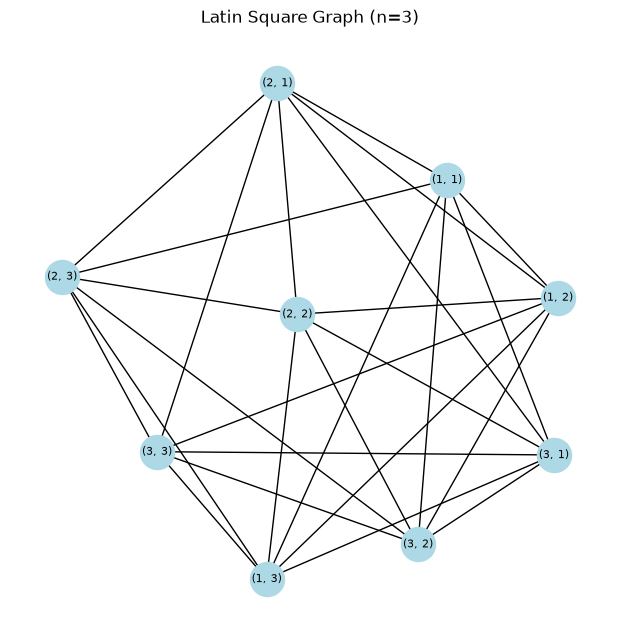

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# First Create Initial Matrix Outline
n = 3
mat = []
node_rlist = []
node_clist = []
for i in range(n):
    mat.append([0] *n)
#print(*mat, sep="\n")

# Start to insert values
for r in range(n):
    for c in range(n):
        mat[r][c] = ((r+c) % n)+1
        node_rlist.append(r+1)
        node_clist.append(c+1)

node_list = list(zip(node_rlist, node_clist))
print("Latin Square with %dx%d grid\n" % (n,n))
print(*mat, sep="\n")
print("\n")
print("Nodes of the Graph: \n", node_list)
print("\n")

LSG = nx.Graph()
LSG.add_nodes_from(node_list)

# Create 2 different tuples of the same node list to compare and make sure that the graph is built to LSG specifications
pc = 0
for i in range(len(node_list)):
    for j in range(i+1, len(node_list)):
        node1 = node_list[i]
        node2 = node_list[j]
        pc+=1

# check for same row, column or number which are conditions to identify neighbors (k degree
        if node1[0] == node2[0] or node1[1] == node2[1] or mat[node1[0]-1][node1[1]-1] == mat[node2[0]-1][node2[1]-1]:
           # print("connected")
            LSG.add_edge(node1, node2)
        #print(f" pair count: {pc}, node1: {node1} & node2: {node2} \n")

        
            


print("The number of edges the Latin Square Graph has: ", LSG.number_of_edges())
print("\n")
print("The degrees or number of neighbors the Latin Square Graph has: \n", dict(LSG.degree()))

# a new loop to check for common and uncommon neighbors
lambda_list = set()  #set of common neighbors
mu_list = set()      # set of uncommon neighbors

pc = 0
for i in range(len(node_list)):
    for j in range(i+1, len(node_list)):
        node1 = node_list[i]
        node2 = node_list[j]
        pc+=1

        common_neighbors = set(LSG[node1]) & set(LSG[node2])
        count = len(common_neighbors)


        if LSG.has_edge(node1, node2):
            lambda_list.add(count)
        else:
            mu_list.add(count)

print(f"calculated value: λ = {lambda_list}, predicted value: λ = n = {n}")
print(f"calculated value: μ = {mu_list}, predicted μ = 6")

#draw graph
pos = nx.spring_layout(LSG, seed=42)
plt.figure(figsize=(6,6))
nx.draw(LSG, pos, with_labels=True, node_color='lightblue', node_size=600, font_size=8)
plt.title(f"Latin Square Graph (n={n})")
plt.show()

#### 2.2: Strongly Regular Graphs in Abstract Algebra 

The use of strongly regular graphs in abstract algebra is primarily seen in group theory, which is also known as the study of symmetry. In comparison to proving how Strongly Regular graphs are prevalent in combinatorics where the criteria was proven through hand counting, in group theory λ, and μ remain constant through the use of pure symmetry.

- In abstract algebra, a permutation group is a group with G, paired with a function that reorganizes the elements of a set X. Where every part of G plays a role in reorganizing the pieces of X.
- The group G is transitive if any part of X can be mapped to any other. This means any element can be reached starting from any other element in the group.
- A group is of rank 3 when G has 3 orbits, where the pairs split into D, E and F, where D is x=y. Meanwhile if E and F are symmetric then they have 2 different graphs, (X, E) which refers to an adjacent or edge, and other one which is (X,F) which refers to the complement or non-adjacent.
- Automorphism is where vertices are relabeled or reorganized to ensure that the adjacency relationship is preserved, this causes every edge and non-edge to be shuffled without disturbing their characteristics.
- Since G is transitive, for adjacent pairs, it allows for any adjacent pair of vertices to be mapped out by automorphisms to any other adjacent pair. In this way automorphism can retain the exact graph structure, while simultaneously preserving the number of common neighbors. This causes every adjacent pair to share the same constant λ, and similarly every non-adjacent pair must share the same constant μ.

Therefore, the amount of common neighbors of 2 vertices relies only on whether they are equal, adjacent, or nonadjacent, and does not depend on the chosen vertices.

#### 2.3: Strongly Regular Graphs in Coding Theory

In coding theory Strongly Regular Graphs mainly show up in the Hoffman Bound. This bound creates a strict upper limit on the size of a clique, which is a set of vertices that are all mutually connected to one another, in a strongly regular graph ($|D| ≤ 1 + k/(-s)$) and is based on the graph's degree $k$ and it's smallest eigenvalue $s$. In other words, the subset of a strongly regular graph can never go over the size limit found based on the graph's spectrum, regardless of how the graph is otherwise structured.

In [ ]:
# build petersen graph
c = nx.petersen_graph()
a = nx.to_numpy_array(c) # turn grpah into numpy array in order to list the eigenvalues of the graph
eigenvalues = np.linalg.eigvalsh(a)
print(f"Eigenvalues: {eigenvalues}\n")

#find k the largest value
k = np.max(eigenvalues)
print(f"largest eigenvalue k: {k}\n")

# find s the smallest eigenvalue
s = np.min(eigenvalues)
print(f"smallest eigenvalue s: {s}\n")

#calculate Hoffman Bound 
D = 1+(k/-s)
print(f"Hoffman Bound on clique size: {D}\n")

# find actual max clique size
b = list(nx.find_cliques(c))
print(f"Maximal Cliques found: {b}\n")


largest_size = max(len(clique) for clique in b)
print(f"Actual largest clique size: {largest_size}")

Eigenvalues: [-2. -2. -2. -2.  1.  1.  1.  1.  1.  3.]

largest eigenvalue k: 3.0

smallest eigenvalue s: -2.000000000000001

Hoffman Bound on clique size: 2.499999999999999

Maximal Cliques found: [[0, 1], [0, 4], [0, 5], [2, 1], [2, 3], [2, 7], [3, 8], [3, 4], [6, 8], [6, 1], [6, 9], [7, 9], [7, 5], [8, 5], [9, 4]]

Actual largest clique size: 2


- Using the Petersen graph to apply the Hoffman Bound, it is found that k = 3 and s ≈ -2, leading to a bound of $|D| ≤ 2.5$, but the size of a clique must be a whole number, which entails that the cliques of the Petersen graph must have no more than 2 vertices. This is found to be true as the actual size of the largest clique has exactly 2 vertices, which illustrates our theoretical prediction, showing that the eigenvalue rule belonging to strongly regular graphs restricts the structure that can exist in it.

### 3: Famous Strongly Regular Graphs

#### 3.1: Petersen Graph

The Petersen Graph was built by a Danish mathematician named Julius Petersen. He specifically constructed this graph to refute a mathematical conjecture that was widely known. It claimed that any connected, bridgeless cubic graph could always be edge colored with just 3 colors. So Petersen went out of his way to create a graph that fulfilled all the conditions, it was connected, bridgeless and cubic, but because of it's specific structure it could not be edge-colored with 3 colors. The Petersen graph is also the unique strongly regular graph with parameters (v, k, λ, µ) = (10, 3, 0, 1), where no other graph has the same set of parameters. It is also a complement of the triangular graph T(5) which happens to be a specific case of another well known Strongly Regular graph, the Johnson graph.

Edges in Petersen Graph: 15

Nodes in Line Graph: 15

distinct colors: 4



Text(0.5, 1.0, 'Edge-Colored Petersen Graph')

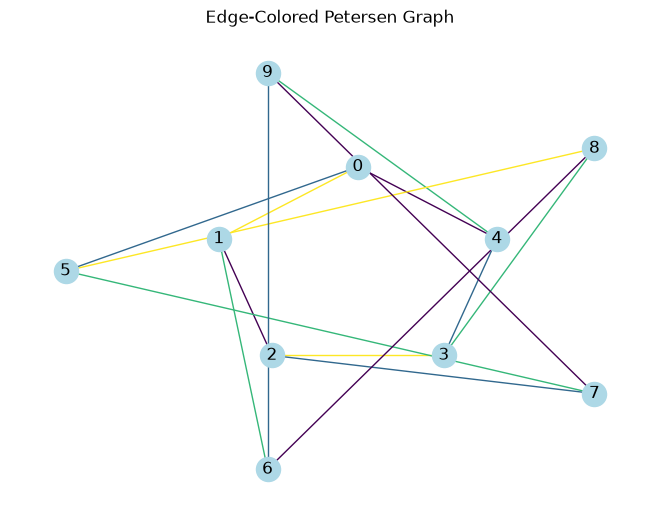

In [ ]:
g = nx.petersen_graph() #Petersen Graph
l = nx.line_graph(g) #turns above petersen graph into a line graph

print(f"Edges in Petersen Graph: {g.number_of_edges()}\n")
print(f"Nodes in Line Graph: {l.number_of_nodes()}\n")

lc = nx.coloring.greedy_color(l)
#print(lc)

colors = set(lc.values())
print(f"distinct colors: {len(colors)}\n")

edgelist = list(lc.keys())
for i in range(len(edgelist)):
    for j in range(i+1, len(edgelist)):
        edge1 = edgelist[i]
        edge2 = edgelist[j]
        if edge1[0] in edge2 or edge1[1] in edge2:
           if lc[edge1] == lc[edge2]:
               print(f"Conflict between {edge1} & {edge2}")

edge_colors = []
for u, v in g.edges():
    edge_colors.append(lc.get((u,v)))
    

pos = nx.shell_layout(g, nlist=[list(range(5)), list(range(5, 10))])
nx.draw(g, pos, with_labels=True, edge_color=edge_colors, node_color='lightblue')
plt.title(f"Edge-Colored Petersen Graph")

- To go through this historical conjecture, the edge coloring method was followed using a greedy algorithm, by turning a Petersen graph into a Line graph, in order to compare the number of edges and nodes respectively. To confirm that Petersen graphs can't be edge colored with 3 colors, the greedy algorithm required 4 colors for all 15 edges. Although the algorithm doesn't prove that using 3 colors is completely impossible, the outcome is sufficient enough to align with established theory that the chromatic index is 4. This follows Julius Petersen's claim of 4 colors instead of 3, as a strong counterexample.

#### 3.2: Johnson Graph

Johnson graphs, as previously mentioned are another well known case of Strongly Regular Graphs. It is made up of a set $Ω$ and an integer $d$ $≥$ 0, making the Johnson graph $J$($Ω$, $d$), and its vertices are all possible $d$-element subsets of $Ω$. If 2 subsets of a Johnson graph share $d-1$ elements, between the two subsets, meaning that they now share an edge. When $d=2$ it is a specific case of the Johnson graph known as the triangular graph $T(m)$. Meanwhile, the complement of the triangular graph $T(5)$ is the Petersen graph.


#### 3.3: Hamming Graph

Similar to Johnson graphs, Hamming graphs are also composed of a set $Ω$ and an integer $d$ $≥$ 0, but unlike Johnson graphs, which use subsets, the Hamming graph uses tuples $H(d,Ω)$. Here the vertices of a Hamming graph are all possible $d$-tuples of the set $Ω$, and if two of these tuples differ by exactly one position, then they are adjacent and this is known as Hamming distance 1. A special case of the Hamming graph occurs when $H(2,q)$ as this structure is relatively close to the build of Latin Square Graphs, without the same number rule. This specific $H(2,q)$ is known as a Lattice graph $L_{2}(q)$ or the $q×q$ grid, a concept which is very similar to the one introduced at the beginning.

## Part Three: ADJACENCY MATRICES

This section explores how graphs can be represented with matrices, what information can be read from those matrices, how weighted graphs change the representation, and why adjacency matrices are unusually interesting for strongly regular graphs.

### 1: Adjacency Matrix Definition

A graph $G(V,E)$ can be translated into a numerical representation which we call an adjacency matrix. Each vertex corresponds to one row and one column of the matrix. For a simple graph, if two vertices $i$ and $j$ are connected by an edge then $A_{ij}=1$, otherwise $A_{ij}=0$. The adjacency matrix for a simple undirected graph is symmetric, as an edge connecting vertex $i$ to vertex $j$ also connects $j$ to $i$. The diagonal entries are 0 as a vertex cannot be connected to itself in a simple undirected graph. (Lehman et al., 2010)

### 2: Translating a Graph to an Adjacency Matrix

In order to construct an adjacency matrix, choose an ordering for the vertices. Each row and column represents one vertex. Enter 1 for every pair that is connected by an edge and 0 otherwise. Since undirected edges work in both directions, the matrix contains matching entries across the main diagonal. (Lehman et al., 2010)

Here is an example with the Petersen Graph and its adjacency matrix.

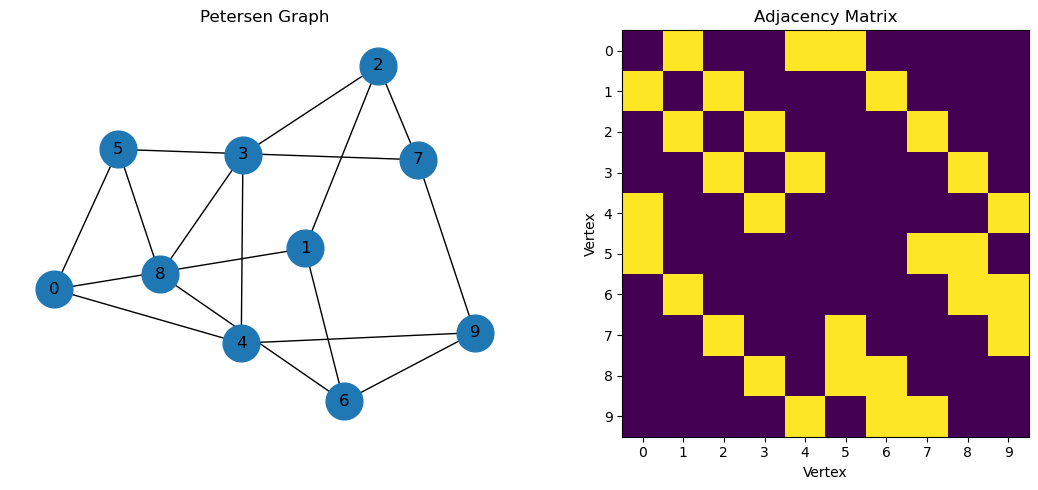

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Make the Petersen graph and its adjacency matrix
G = nx.petersen_graph()
A = nx.to_numpy_array(G, dtype=int)

# Graph and Matrix Display
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

nx.draw(G, with_labels=True, node_size=700, ax=axes[0])
axes[0].set_title("Petersen Graph")

axes[1].imshow(A)
axes[1].set_title("Adjacency Matrix")
axes[1].set_xlabel("Vertex")
axes[1].set_ylabel("Vertex")
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))

plt.tight_layout()
plt.show()

Figure 1. The Petersen graph and its adjacency matrix.

### 3: Insights from an Adjacency Matrix 

The degree of a vertex is the number of entries equal to 1, since each 1 represents a neighbor of the vertex. Powers of the adjacency matrix contain additional information about movement through the graph. In particular, the entry $(A^2)_{ij}$ counts the number of two-step walks from vertex $i$ to vertex $j$. For two different vertices, this also gives the number of common neighbors they share. (Lehman et al., 2010)

In [ ]:
# degree of each vertex given by the sum of the row
degrees = A.sum(axis=1)

# A^2 contains the number of two step walks
A2 = A @ A

print("Degree of each vertex:")
print(degrees)

print("\nA squared:")
print(A2)

Degree of each vertex:
[3 3 3 3 3 3 3 3 3 3]

A squared:
[[3 0 1 1 0 0 1 1 1 1]
 [0 3 0 1 1 1 0 1 1 1]
 [1 0 3 0 1 1 1 0 1 1]
 [1 1 0 3 0 1 1 1 0 1]
 [0 1 1 0 3 1 1 1 1 0]
 [0 1 1 1 1 3 1 0 0 1]
 [1 0 1 1 1 1 3 1 0 0]
 [1 1 0 1 1 0 1 3 1 0]
 [1 1 1 0 1 0 0 1 3 1]
 [1 1 1 1 0 1 0 0 1 3]]


Considering the Petersen graph, every row sums to 3, meaning each vertex has degree 3. In $A^2$, the diagonal entries are 3 as well. The off-diagonal entries show the number of common neighbors shared by pairs of different vertices.

### 4: Weighted Graphs and Adjacency Matrices

In a weighted graph, the entries of the adjacency matrix do not have to be only 0 or 1. Instead, $A_{ij}$ can contain the numerical weight 
assigned to the edge between vertices $i$ and $j$. Depending on the graph, this weight might represent distance, cost, capacity, or another quantity. (Lehman et al., 2010) The sum of the row then represents the weighted degree, or total strength, instead of only the number of neighbors.

### 5: Strongly Regular Graphs and Adjacency Matrices

A strongly regular graph has parameters $(v,k,\lambda,\mu)$ with $v$ vertices where each vertex has a degree of $k$, every pair of adjacent vertices has $\lambda$ common neighbors, and each pair of non-adjacent vertices has $\mu$ common neighbors.
Because the entries of $A^2$ count two-step walks, they also count common neighbors, so the strongly regular condition can be expressed as
$$
A^2 = kI + \lambda A + \mu(J-I-A).
$$
$I$ is the identity matrix and $J$ is the matrix whose entries are all 1. This equation expresses the common neighbor structure of a strongly regular graph as a single matrix identity. (Spielman, 2009)




### 5.1: Petersen Graph

The Petersen graph is an SRG $(10,3,0,1)$. The graph has 10 vertices, where each vertex has a degree of 3, adjacent vertices have 0 common neighbors, and non-adjacent vertices have 1 common neighbor.
If we substitute these values into the general identity, we get
$$
A^2 = 2I - A + J.
$$

In [ ]:
# Verifying the strongly regular graph identity for the Petersen graph
n = A.shape[0]
I = np.eye(n, dtype=int)
J = np.ones((n, n), dtype=int)

left_side = A @ A
right_side = 2 * I - A + J

print("Does A^2 = 2I - A + J?")
print(np.array_equal(left_side, right_side))

Does A^2 = 2I - A + J?
True


The output `True` verifies that the Petersen graph satisfies the adjacency-matrix identity associated with its strongly regular graph parameters.

### 5.2: Cycle Graph $C_5$

The cycle graph $C_5$ is an SRG with parameters (5,2,0,1). (Spielman, 2009) Each vertex has a degree of 2, adjacent vertices have no common neighbors, and non-adjacent vertices have exactly one common neighbor. Its matrix identity is
$$
A^2 = I - A + J.
$$

In [ ]:
# C5 and verifying its strongly regular graph identity
C5 = nx.cycle_graph(5)
B = nx.to_numpy_array(C5, dtype=int)

I5 = np.eye(5, dtype=int)
J5 = np.ones((5, 5), dtype=int)

print("C5 adjacency matrix:")
print(B)

print("\nDegree of each vertex:")
print(B.sum(axis=1))

print("\nDoes B^2 = I - B + J?")
print(np.array_equal(B @ B, I5 - B + J5))

C5 adjacency matrix:
[[0 1 0 0 1]
 [1 0 1 0 0]
 [0 1 0 1 0]
 [0 0 1 0 1]
 [1 0 0 1 0]]

Degree of each vertex:
[2 2 2 2 2]

Does B^2 = I - B + J?
True


The $C_5$ computation gives a degree of 2 for each vertex and returns True for its SRG matrix identity. Both the $C_5$ and the Petersen graph show the same type of strongly regular matrix structure.

## References

Ajorlou, A. (2018). *Lecture 2: Introduction to graph theory* [Lecture notes]. MIT OpenCourseWare.

Brouwer, A. E., & Van Maldeghem, H. (2022). *Strongly regular graphs*. Cambridge University Press. https://homepages.cwi.nl/~aeb/math/srg/rk3/srgw.pdf

Lehman, E., Leighton, F. T., & Meyer, A. R. (2010). Graph theory. In *Mathematics for computer science* (chap. 5). MIT OpenCourseWare. https://ocw.mit.edu/courses/6-042j-mathematics-for-computer-science-fall-2010/f471f7b7034fabe8bbba5507df7d307f_MIT6_042JF10_chap05.pdf

Nykamp, D. Q. (n.d.). *An introduction to networks*. Math Insight. https://mathinsight.org/network_introduction

Sedgewick, R., & Wayne, K. (n.d.). *Undirected graphs*. In *Algorithms* (4th ed.). https://algs4.cs.princeton.edu/41graph/

Spielman, D. A. (2009). *Lecture 23: Strongly regular graphs, part 1* [Lecture notes]. Yale University. https://www.cs.yale.edu/homes/spielman/561/2009/lect23-09.pdf